# Recurrent Neural Networks (RNN) — Step by Step
#### This notebook introduces the basics of RNNs: equations, unfolding, feed-forward, backpropagation through time (BPTT), and implementations with NumPy and PyTorch.
---

## 1. Recurrent Neuron Unit — Equations

A single recurrent neuron processes input $x_t$ at time $t$ and previous hidden state $h_{t-1}$:

\[
a_t = W_{xh} x_t + W_{hh} h_{t-1} + b_h
\]

\[
h_t = \tanh(a_t)
\]

\[
y_t = W_{hy} h_t + b_y
\]


## 2. NumPy Implementation of a Recurrent Neuron


In [1]:

import numpy as np

class RecurrentNeuron:
    def __init__(self, d_in, d_h, d_out):
        rng = np.random.RandomState(1)
        self.W_xh = rng.randn(d_h, d_in) * 0.1
        self.W_hh = rng.randn(d_h, d_h) * 0.1
        self.b_h  = np.zeros((d_h, 1))
        self.W_hy = rng.randn(d_out, d_h) * 0.1
        self.b_y  = np.zeros((d_out, 1))

    def forward(self, x_t, h_prev):
        a_t = self.W_xh @ x_t + self.W_hh @ h_prev + self.b_h
        h_t = np.tanh(a_t)
        y_t = self.W_hy @ h_t + self.b_y
        return y_t, h_t, a_t

# Test with random input
cell = RecurrentNeuron(d_in=3, d_h=4, d_out=2)
x = np.random.randn(3,1)
h_prev = np.zeros((4,1))
y, h, a = cell.forward(x, h_prev)
print("Output y:", y.ravel())
print("Hidden h:", h.ravel())


Output y: [-0.02143992 -0.01777045]
Hidden h: [ 0.18267272 -0.08314006  0.18265394 -0.01251412]


## 3. RNN Unfolding Through Time
An RNN across $T$ time steps is the same cell applied repeatedly with shared weights.

ASCII illustration:
```
x1 -> [RNN] -> h1 -> [RNN] -> h2 -> ... -> hT
```


## 4. Full RNN (NumPy) with Forward and Backpropagation Through Time (BPTT)


In [2]:

class SimpleRNN:
    def __init__(self, d_in, d_h, d_out, lr=0.01):
        rng = np.random.RandomState(0)
        self.W_xh = rng.randn(d_h, d_in) * 0.1
        self.W_hh = rng.randn(d_h, d_h) * 0.1
        self.b_h  = np.zeros((d_h,1))
        self.W_hy = rng.randn(d_out, d_h) * 0.1
        self.b_y  = np.zeros((d_out,1))
        self.lr = lr
        self.d_h = d_h

    def forward(self, X):
        T = len(X)
        h = np.zeros((T+1, self.d_h, 1))
        a = np.zeros((T, self.d_h, 1))
        y = np.zeros((T, self.W_hy.shape[0], 1))
        for t in range(T):
            a[t] = self.W_xh @ X[t] + self.W_hh @ h[t] + self.b_h
            h[t+1] = np.tanh(a[t])
            y[t] = self.W_hy @ h[t+1] + self.b_y
        return y, h, a

    def compute_loss(self, Y_pred, Y_true):
        loss = 0.0
        for t in range(len(Y_true)):
            diff = Y_pred[t] - Y_true[t]
            loss += 0.5 * np.sum(diff**2)
        return loss

    def bptt(self, X, Y_true):
        T = len(X)
        y, h, a = self.forward(X)
        dW_hy = np.zeros_like(self.W_hy)
        db_y  = np.zeros_like(self.b_y)
        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        db_h  = np.zeros_like(self.b_h)

        d_a_next = np.zeros((self.d_h,1))
        for t in reversed(range(T)):
            dy = (y[t] - Y_true[t])
            dW_hy += dy @ h[t+1].T
            db_y  += dy
            dh = self.W_hy.T @ dy + self.W_hh.T @ d_a_next
            d_a = dh * (1 - np.tanh(a[t])**2)
            dW_xh += d_a @ X[t].T
            dW_hh += d_a @ h[t].T
            db_h  += d_a
            d_a_next = d_a

        for g in [dW_hy, db_y, dW_xh, dW_hh, db_h]:
            np.clip(g, -5, 5, out=g)

        self.W_hy -= self.lr * dW_hy
        self.b_y  -= self.lr * db_y
        self.W_xh -= self.lr * dW_xh
        self.W_hh -= self.lr * dW_hh
        self.b_h  -= self.lr * db_h

        return self.compute_loss(y, Y_true)


### Training on Toy Sequence (Sine Wave Prediction)


In [3]:

import math

# Prepare toy dataset
seq_len = 20
data = []
for start in np.linspace(0, 2*math.pi, 50):
    xs = [np.array([[math.sin(start + i*0.1)]]) for i in range(seq_len)]
    ys = [np.array([[math.sin(start + (i+1)*0.1)]]) for i in range(seq_len)]
    data.append((xs, ys))

# Train
rnn = SimpleRNN(d_in=1, d_h=16, d_out=1, lr=0.005)
for epoch in range(100):
    total_loss = 0
    for X_seq, Y_seq in data:
        loss = rnn.bptt(X_seq, Y_seq)
        total_loss += loss
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(data):.4f}")


Epoch 0, Loss: 1.3852
Epoch 20, Loss: 0.0166
Epoch 40, Loss: 0.0123
Epoch 60, Loss: 0.0282
Epoch 80, Loss: 0.0277


## 5. PyTorch Implementation of RNN


Starting training...
Epoch: 0, Avg Loss: 0.476544
Epoch: 100, Avg Loss: 0.315115

Training complete. Making predictions...


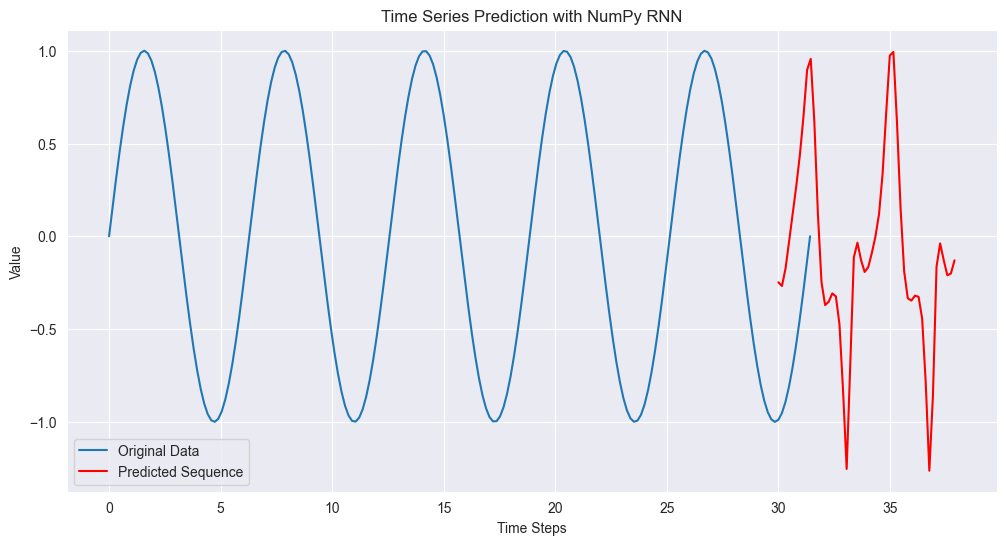

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Activation functions and their derivatives
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(x):
    return x * (1 - x)

# 2. RNN Class Implementation
class RNN:
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Initialize dimensions
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        # Initialize weights and biases with random values from a uniform distribution
        self.Wxh = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim)) # Input to hidden
        self.Whh = np.random.uniform(-0.1, 0.1, (hidden_dim, hidden_dim)) # Hidden to hidden (recurrent)
        self.Why = np.random.uniform(-0.1, 0.1, (output_dim, hidden_dim)) # Hidden to output
        self.bh = np.zeros((hidden_dim, 1)) # Hidden bias
        self.by = np.zeros((output_dim, 1)) # Output bias

        # Initialize gradients for backpropagation
        self.dWxh, self.dWhh, self.dWhy = np.zeros_like(self.Wxh), np.zeros_like(self.Whh), np.zeros_like(self.Why)
        self.dbh, self.dby = np.zeros_like(self.bh), np.zeros_like(self.by)

    def forward(self, inputs):
        # Store hidden states and outputs for backpropagation
        self.h_states = {}
        self.y_outputs = {}
        self.h_states[-1] = np.zeros((self.hidden_dim, 1))

        for t in range(len(inputs)):
            # Convert input into the correct shape
            x_t = inputs[t].reshape(self.input_dim, 1)

            # Update hidden state
            self.h_states[t] = tanh(np.dot(self.Wxh, x_t) + np.dot(self.Whh, self.h_states[t-1]) + self.bh)

            # Calculate output
            self.y_outputs[t] = np.dot(self.Why, self.h_states[t]) + self.by

        return self.y_outputs

    def backward(self, inputs, targets, learning_rate):
        # Reset gradients
        self.dWxh, self.dWhh, self.dWhy = np.zeros_like(self.Wxh), np.zeros_like(self.Whh), np.zeros_like(self.Why)
        self.dbh, self.dby = np.zeros_like(self.bh), np.zeros_like(self.by)
        dh_next = np.zeros_like(self.h_states[0])

        for t in reversed(range(len(inputs))):
            x_t = inputs[t].reshape(self.input_dim, 1)

            # Output error
            dy = self.y_outputs[t] - targets[t].reshape(self.output_dim, 1)

            # Backpropagate to output weights and bias
            self.dWhy += np.dot(dy, self.h_states[t].T)
            self.dby += dy

            # Backpropagate to hidden state
            dh = np.dot(self.Why.T, dy) + dh_next

            # Backpropagate through tanh activation
            dh_raw = dtanh(self.h_states[t]) * dh

            # Backpropagate to input and recurrent weights/bias
            self.dWxh += np.dot(dh_raw, x_t.T)
            self.dWhh += np.dot(dh_raw, self.h_states[t-1].T)
            self.dbh += dh_raw

            # Set next hidden state gradient for Backpropagation Through Time (BPTT)
            dh_next = np.dot(self.Whh.T, dh_raw)

        # Clip gradients to prevent exploding gradients
        for grad in [self.dWxh, self.dWhh, self.dWhy, self.dbh, self.dby]:
            np.clip(grad, -1, 1, out=grad)

        # Update weights
        self.Wxh -= learning_rate * self.dWxh
        self.Whh -= learning_rate * self.dWhh
        self.Why -= learning_rate * self.dWhy
        self.bh -= learning_rate * self.dbh
        self.by -= learning_rate * self.dby

    def train(self, inputs, targets, epochs, learning_rate):
        for epoch in range(epochs):
            # Forward pass
            y_preds = self.forward(inputs)

            # Calculate loss (Mean Squared Error)
            loss = np.mean([(y_preds[t] - targets[t].reshape(self.output_dim, 1))**2 for t in range(len(inputs))])

            # Backward pass
            self.backward(inputs, targets, learning_rate)

            if epoch % 100 == 0:
                print(f'Epoch: {epoch}, Loss: {loss:.6f}')
        return y_preds

    def predict(self, start_sequence):
        # Reset hidden state for new sequence
        self.h_states = {-1: np.zeros((self.hidden_dim, 1))}

        # Process the start sequence to set the final hidden state
        for t in range(len(start_sequence)):
            x_t = start_sequence[t].reshape(self.input_dim, 1)
            self.h_states[t] = tanh(np.dot(self.Wxh, x_t) + np.dot(self.Whh, self.h_states[t-1]) + self.bh)

        # Make a prediction for the next step
        last_hidden_state = self.h_states[len(start_sequence) - 1]
        next_output = np.dot(self.Why, last_hidden_state) + self.by

        return next_output

# 3. Create a synthetic time series dataset
def create_sine_wave_data(sequence_length=50):
    t = np.linspace(0, 10 * np.pi, 200)
    data = np.sin(t)

    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])

    return np.array(X), np.array(y)

# 4. Prepare and train the model
if __name__ == '__main__':
    # Generate and preprocess data
    X_data, y_data = create_sine_wave_data(sequence_length=10)

    # Reshape for RNN input (samples, timesteps, features)
    X_train = np.array([X_data[i] for i in range(len(X_data))])
    y_train = np.array([y_data[i] for i in range(len(y_data))])

    # Model parameters
    input_size = 1
    hidden_size = 10
    output_size = 1

    # Initialize and train the RNN
    rnn = RNN(input_dim=input_size, hidden_dim=hidden_size, output_dim=output_size)

    # The training loop requires input sequences and corresponding target values.
    # The example needs to be restructured to feed individual sequences.
    print("Starting training...")
    epochs = 200
    learning_rate = 0.001

    for epoch in range(epochs):
        epoch_loss = 0
        for i in range(len(X_train)):
            inputs = X_train[i].reshape(-1, 1) # reshape (timesteps, 1)
            targets = y_train[i].reshape(1, 1)  # reshape (1, 1)

            # Forward pass
            y_preds_dict = rnn.forward(inputs)
            y_pred = y_preds_dict[len(inputs)-1] # Get final prediction

            # Backward pass
            y_preds_full = np.array(list(y_preds_dict.values())).flatten()
            targets_full = np.array([y_train[i] for _ in range(len(inputs))])

            # Recompute loss on the full sequence for printing
            loss = np.mean((y_preds_full - targets_full)**2)
            epoch_loss += loss

            # The backward function is specific to a sequence
            rnn.backward(inputs, np.array([y_train[i] for _ in range(len(inputs))]).flatten(), learning_rate)

        if epoch % 100 == 0:
            print(f'Epoch: {epoch}, Avg Loss: {epoch_loss/len(X_train):.6f}')

    # 5. Make predictions with the trained model
    print("\nTraining complete. Making predictions...")

    # Use the last 10 points of the training data to start the prediction
    start_sequence = X_train[-1]

    # Generate a forecast for 50 steps
    predicted_sequence = []
    current_input = start_sequence
    for _ in range(50):
        # Get the prediction for the next step
        next_step_pred = rnn.predict(current_input).item()
        predicted_sequence.append(next_step_pred)

        # Update the sequence for the next prediction
        current_input = np.append(current_input[1:], next_step_pred)

    # 6. Plot the results with corrected indices
plt.figure(figsize=(12, 6))

# Plot the original data
# The original data has a length equal to the number of samples plus the sequence length
# minus one. Let's create the correct x-axis for it.
t = np.linspace(0, 10 * np.pi, 200) # Re-generate the full time series
plt.plot(t, np.sin(t), label='Original Data')

# Plot the predicted sequence
# Start plotting the predicted sequence after the training data ends.
# The original data ends at index 199. The start of the predicted sequence is at index 200.
prediction_start_t = t[-len(start_sequence)]
predicted_t = np.linspace(prediction_start_t, prediction_start_t + 50 * (t[1]-t[0]), 50)
plt.plot(predicted_t, predicted_sequence, 'r-', label='Predicted Sequence')

plt.title("Time Series Prediction with NumPy RNN")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()



#### Your basic NumPy RNN is likely failing to accurately predict the sine wave due to the vanishing gradient problem, a fundamental limitation of simple RNN architectures. The simple RNN struggles to learn long-term dependencies, which is critical for a periodic pattern like a sine wave

In [ ]:
# Create a new LSTM cell class within your existing code
class LSTMCell:
    def __init__(self, input_dim, hidden_dim):
        # Weight and bias initialization (can be improved)
        self.Wf = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim + hidden_dim))
        self.bf = np.zeros((hidden_dim, 1))
        self.Wi = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim + hidden_dim))
        self.bi = np.zeros((hidden_dim, 1))
        self.Wc = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim + hidden_dim))
        self.bc = np.zeros((hidden_dim, 1))
        self.Wo = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim + hidden_dim))
        self.bo = np.zeros((hidden_dim, 1))

    # You would then need to implement forward and backward passes for this cell
    # and integrate it into your main training loop.


In [5]:
pip install keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\Administrator\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## 6. Sentimental Analysis

In [19]:
# =====================================
# 1️⃣ Import Required Libraries
# =====================================

import nltk
import pandas as pd
from textblob import Word
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from tensorflow.keras.utils import to_categorical

# Download required NLTK data (only once)
#nltk.download('stopwords')
#nltk.download('wordnet')

# =====================================
# 2️⃣ Load Dataset
# =====================================

# Replace with your dataset file
data = pd.read_csv('data.csv')

# Example expected columns:
# data.head() should show something like:
# | sentences                     | sentiment |
# |-------------------------------|------------|
# | "The stock performed well..." | "positive" |

print("Data Sample:\n", data.head())

# =====================================
# 3️⃣ Data Cleaning Function
# =====================================

def cleaning(df, stop_words):
    # Convert to lowercase
    df['Sentence'] = df['Sentence'].apply(lambda x: ' '.join(x.lower() for x in x.split()))

    # Remove digits/numbers
    df['Sentence'] = df['Sentence'].str.replace(r'\d+', '', regex=True)

    # Remove stopwords
    df['Sentence'] = df['Sentence'].apply(
        lambda x: ' '.join(word for word in x.split() if word not in stop_words)
    )

    # Lemmatization (reduce to root form)
    df['Sentence'] = df['Sentence'].apply(
        lambda x: ' '.join([Word(word).lemmatize() for word in x.split()])
    )
    return df

# Clean dataset
stop_words = stopwords.words('english')
data_cleaned = cleaning(data, stop_words)

# =====================================
# 4️⃣ Tokenization and Padding
# =====================================

tokenizer = Tokenizer(num_words=500, split=' ')
tokenizer.fit_on_texts(data_cleaned['Sentence'].values)

X = tokenizer.texts_to_sequences(data_cleaned['Sentence'].values)
X = pad_sequences(X)

# =====================================
# 5️⃣ Encode Target Labels
# =====================================

le = LabelEncoder()
y = le.fit_transform(data_cleaned['Sentiment'])  # assumes 'sentiment' column exists
y = to_categorical(y)  # convert to one-hot encoding

# Split data into training/testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# 6️⃣ Build the LSTM Model
# =====================================

model = Sequential()
model.add(Embedding(input_dim=500, output_dim=120))   # ← removed input_length
model.add(SpatialDropout1D(0.4))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(y.shape[1], activation='softmax'))

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# =====================================
# 7️⃣ Train the Model
# =====================================

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1,
    validation_split=0.1
)

# =====================================
# 8️⃣ Evaluate the Model
# =====================================

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test.argmax(axis=1)

print("\n✅ Accuracy:", accuracy_score(y_true, y_pred_classes))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_true, y_pred_classes))
print("\n📋 Classification Report:\n", classification_report(y_true, y_pred_classes))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Data Sample:
                                             Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.5543 - loss: 0.9625 - val_accuracy: 0.5876 - val_loss: 0.8992
Epoch 2/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.6335 - loss: 0.8241 - val_accuracy: 0.6239 - val_loss: 0.8311
Epoch 3/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6816 - loss: 0.7185 - val_accuracy: 0.6389 - val_loss: 0.7867
Epoch 4/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7046 - loss: 0.6734 - val_accuracy: 0.6325 - val_loss: 0.7844
Epoch 5/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7073 - loss: 0.6464 - val_accuracy: 0.6432 - val_loss: 0.7778
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

✅ Accuracy: 0.679213002566296

📊 Confusion Matrix:
 [[ 76  70  29]
 [ 60 500  62]
 [ 23 131 218]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.43      0.46       175
           1       0.71      0.80      0.76       622
           2       0.71      0.

## 7. Movie Review

In [21]:
import re
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow.keras
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import math
import nltk

In [23]:
data = pd.read_csv('IMDB Dataset.csv')
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [24]:
def remove_tags(string):
    removelist = ""
    result = re.sub('','',string)          #remove HTML tags
    result = re.sub('https://.*','',result)   #remove URLs
    result = re.sub(r'[^w'+removelist+']', ' ',result)    #remove non-alphanumeric characters
    result = result.lower()
    return result
data['review']=data['review'].apply(lambda cw : remove_tags(cw))

In [25]:
#nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
data['review'] = data['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

In [26]:
w_tokenizer = nltk.tokenize.WhitespaceTokenizer()
lemmatizer = nltk.stem.WordNetLemmatizer()
def lemmatize_text(text):
    st = ""
    for w in w_tokenizer.tokenize(text):
        st = st + lemmatizer.lemmatize(w) + " "
    return st
data['review'] = data.review.apply(lemmatize_text)
data

,review,sentiment
0,w w w w w w w w w w w w w w w w w w w w w w w ...,positive
1,w w w w w w w w w w w w w w w,positive
2,w w w w w w w w w w w w w w w w w w w,positive
3,w w w w w w w w w w w,negative
4,w w w w w w w w w w w w w w w w w w,positive
...,...,...
49995,w w w w w w w w w w w w w w w w w w w,positive
49996,w w w w w w w w,negative
49997,w w w w w w w w w w w w,negative
49998,w w w w w w w w w w w w w w w,negative


In [28]:
s = 0.0
for i in data['review']:
    word_list = i.split()
    s = s + len(word_list)
print("Average length of each review : ",s/data.shape[0])
pos = 0
for i in range(data.shape[0]):
    if data.iloc[i]['sentiment'] == 'positive':
        pos = pos + 1
neg = data.shape[0]-pos
print("Percentage of reviews with positive sentiment is "+str(pos/data.shape[0]*100)+"%")
print("Percentage of reviews with negative sentiment is "+str(neg/data.shape[0]*100)+"%")


Average length of each review :  18.714
Percentage of reviews with positive sentiment is 50.0%
Percentage of reviews with negative sentiment is 50.0%


In [32]:
reviews = data['review'].values
labels = data['sentiment'].values
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

In [33]:
train_sentences, test_sentences, train_labels, test_labels = train_test_split(reviews, encoded_labels, stratify = encoded_labels)

In [34]:
# Hyperparameters of the model
vocab_size = 3000 # choose based on statistics
oov_tok = ''
embedding_dim = 100
max_length = 200 # choose based on statistics, for example 150 to 200
padding_type='post'
trunc_type='post'
# tokenize sentences
tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index
# convert train dataset to sequence and pad sequences
train_sequences = tokenizer.texts_to_sequences(train_sentences)
train_padded = pad_sequences(train_sequences, padding='post', maxlen=max_length)
# convert Test dataset to sequence and pad sequences
test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding='post', maxlen=max_length)

In [37]:
# model initialization
model = tensorflow.keras.Sequential([
    tensorflow.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tensorflow.keras.layers.Bidirectional(tensorflow.keras.layers.LSTM(64)),
   tensorflow.keras.layers.Dense(24, activation='relu'),
    tensorflow.keras.layers.Dense(1, activation='sigmoid')
])
# compile model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
# model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
num_epochs = 5
history = model.fit(train_padded, train_labels,
                    epochs=num_epochs, verbose=1,
                    validation_split=0.1)

Epoch 1/5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 120s 110ms/step - accuracy: 0.5094 - loss: 0.6933 - val_accuracy: 0.5037 - val_loss: 0.6929
Epoch 2/5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 142s 134ms/step - accuracy: 0.5121 - loss: 0.6928 - val_accuracy: 0.5211 - val_loss: 0.6915
Epoch 3/5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 131s 124ms/step - accuracy: 0.5124 - loss: 0.6927 - val_accuracy: 0.5299 - val_loss: 0.6912
Epoch 4/5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 170s 162ms/step - accuracy: 0.5124 - loss: 0.6925 - val_accuracy: 0.5259 - val_loss: 0.6918
Epoch 5/5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 205s 164ms/step - accuracy: 0.5145 - loss: 0.6926 - val_accuracy: 0.5320 - val_loss: 0.6915


In [39]:
prediction = model.predict(test_padded)
# Get labels based on probability 1 if p>= 0.5 else 0
pred_labels = []
for i in prediction:
    if i >= 0.5:
        pred_labels.append(1)
    else:
        pred_labels.append(0)
print("Accuracy of prediction on test set : ", accuracy_score(test_labels,pred_labels))

391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step
Accuracy of prediction on test set :  0.51416


In [40]:
# reviews on which we need to predict
sentence = ["The movie was very touching and heart whelming",
            "I have never seen a terrible movie like this",
            "the movie plot is terrible but it had good acting"]
# convert to a sequence
sequences = tokenizer.texts_to_sequences(sentence)
# pad the sequence
padded = pad_sequences(sequences, padding='post', maxlen=max_length)
# Get labels based on probability 1 if p>= 0.5 else 0
prediction = model.predict(padded)
pred_labels = []
for i in prediction:
    if i >= 0.5:
        pred_labels.append(1)
    else:
        pred_labels.append(0)
for i in range(len(sentence)):
    print(sentence[i])
    if pred_labels[i] == 1:
        s = 'Positive'
    else:
        s = 'Negative'
    print("Predicted sentiment : ",s)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
The movie was very touching and heart whelming
Predicted sentiment :  Positive
I have never seen a terrible movie like this
Predicted sentiment :  Positive
the movie plot is terrible but it had good acting
Predicted sentiment :  Positive


## 8. Stock Price Prediction

C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0916 - val_loss: 0.0271
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0243 - val_loss: 0.0261
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0202 - val_loss: 0.0257
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0187 - val_loss: 0.0232
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0177 - val_loss: 0.0220
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0163 - val_loss: 0.0217
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0151 - val_loss: 0.0198
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0135 - val_loss: 0.0169
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0117 - val_loss: 0.0160
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0100 - val_loss: 0.0115
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0086 - val_loss: 0.0090
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

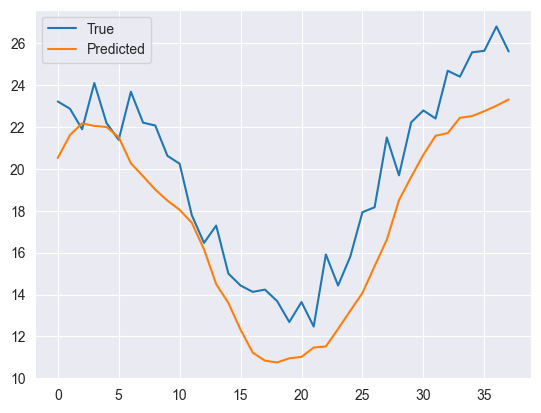

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error

# 1. Generate toy stock data
np.random.seed(0)
days = 200
t = np.arange(days)
prices = 0.05 * t + 10 + 5 * np.sin(0.2 * t) + np.random.normal(scale=1.0, size=days)
df = pd.DataFrame({"day": t, "price": prices})

# 2. Scale & window
data = df["price"].values.reshape(-1,1)
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

def create_dataset(series, window_size=10):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size, 0])
        y.append(series[i + window_size, 0])
    return np.array(X), np.array(y)

window = 10
X, y = create_dataset(data_scaled, window_size=window)
X = X.reshape((X.shape[0], X.shape[1], 1))
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 3. Build LSTM
model = Sequential()
model.add(LSTM(50, input_shape=(window,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# 4. Train & predict
history = model.fit(X_train, y_train, epochs=20, batch_size=8, validation_split=0.1, verbose=1)
y_pred = model.predict(X_test)

# invert scaling
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler.inverse_transform(y_pred)

print("Test MSE:", mean_squared_error(y_test_inv, y_pred_inv))

plt.plot(y_test_inv, label="True")
plt.plot(y_pred_inv, label="Predicted")
plt.legend()
plt.show()

# 5. Save / load
model.save("lstm_stock_model.h5")
# Later, you can load and reuse:
# model2 = load_model("lstm_stock_model.h5")


In [42]:
model.save('my_model.keras')